# Assignment 09: Ensemble Methods & Hyperparameter Tuning
**Name:** Tanmoy Paul

**Dataset:** Adult Census Income (Kaggle, originally UCI) - 32,561 rows, 15 columns.  
**Target:** `income` (`<=50K` / `>50K`)

**Goal:** Compare a single Decision Tree with bagging (Bagging, Random Forest) and boosting (Gradient Boosting, XGBoost) models, tune the best model with Grid Search, Random Search and Optuna, and decide which model and tuning method to ship.

### Import Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     RandomizedSearchCV, cross_val_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from scipy.stats import randint, loguniform
from xgboost import XGBClassifier
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42

---
## Task 1: EDA + Preprocessing
### 1.1 Load the data and basic info

In [4]:
df = pd.read_csv('adult.csv')
print('Shape:', df.shape)
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### 1.2 Missing values (encoded as `?`)

In [7]:
missing = (df == '?').sum()
missing = missing[missing > 0]
print(missing)
print('\nPercentage of rows:')
print((missing / len(df) * 100).round(2))

workclass         1836
occupation        1843
native.country     583
dtype: int64

Percentage of rows:
workclass         5.64
occupation        5.66
native.country    1.79
dtype: float64


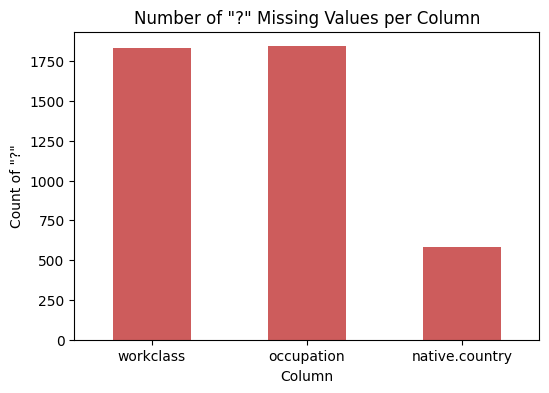

In [8]:
plt.figure(figsize=(6, 4))
missing.plot(kind='bar', color='indianred')
plt.title('Number of "?" Missing Values per Column')
plt.xlabel('Column')
plt.ylabel('Count of "?"')
plt.xticks(rotation=0)
plt.show()

Missing values appear only in **`workclass`** (1,836), **`occupation`** (1,843) and **`native.country`** (583). All three are categorical columns. Before deciding how to handle them, check whether the missingness itself is related to income:

In [9]:
for col in ['workclass', 'occupation', 'native.country']:
    rate = df.groupby(df[col] == '?')['income'].apply(lambda s: (s == '>50K').mean() * 100)
    print(f'{col:15s}  >50K rate  | value present: {rate[False]:.1f}%   value = "?": {rate[True]:.1f}%')

workclass        >50K rate  | value present: 24.9%   value = "?": 10.4%
occupation       >50K rate  | value present: 24.9%   value = "?": 10.4%
native.country   >50K rate  | value present: 24.1%   value = "?": 25.0%


### 1.3 Target distribution (class imbalance)

income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    75.92
>50K     24.08
Name: proportion, dtype: float64


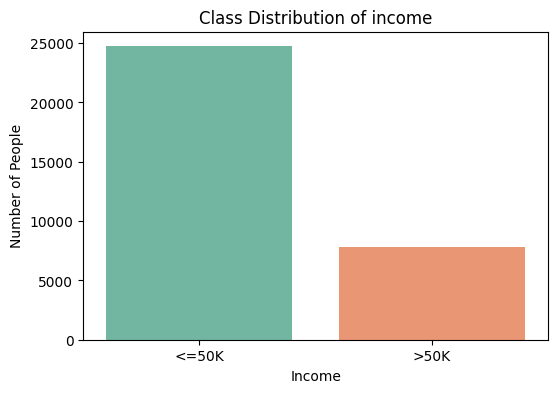

In [10]:
print(df['income'].value_counts())
print((df['income'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=df, hue='income', palette='Set2', legend=False)
plt.title('Class Distribution of income')
plt.xlabel('Income')
plt.ylabel('Number of People')
plt.show()

The classes are **imbalanced: about 76% `<=50K` vs 24% `>50K`**. A model that always predicts `<=50K` would already get ~76% accuracy, so **F1-score** (for the `>50K` class) is reported next to accuracy, and the train-test split is **stratified** to keep the same class ratio in both sets.

### 1.4 Relationship of key features with income

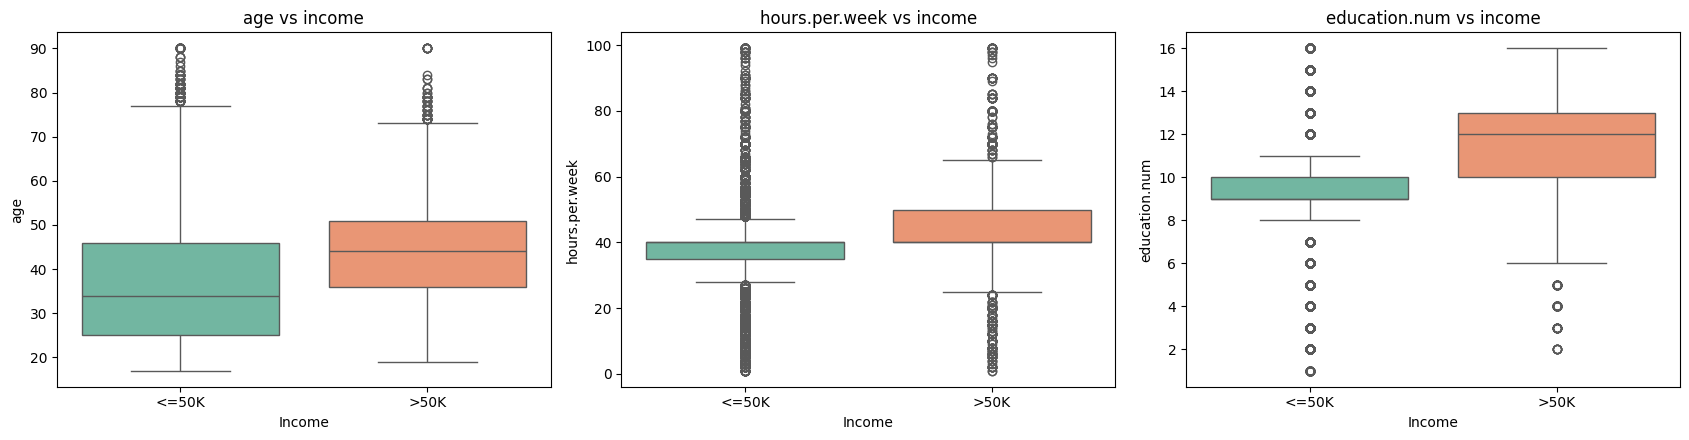

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, ['age', 'hours.per.week', 'education.num']):
    sns.boxplot(x='income', y=col, data=df, hue='income', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{col} vs income')
    ax.set_xlabel('Income')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

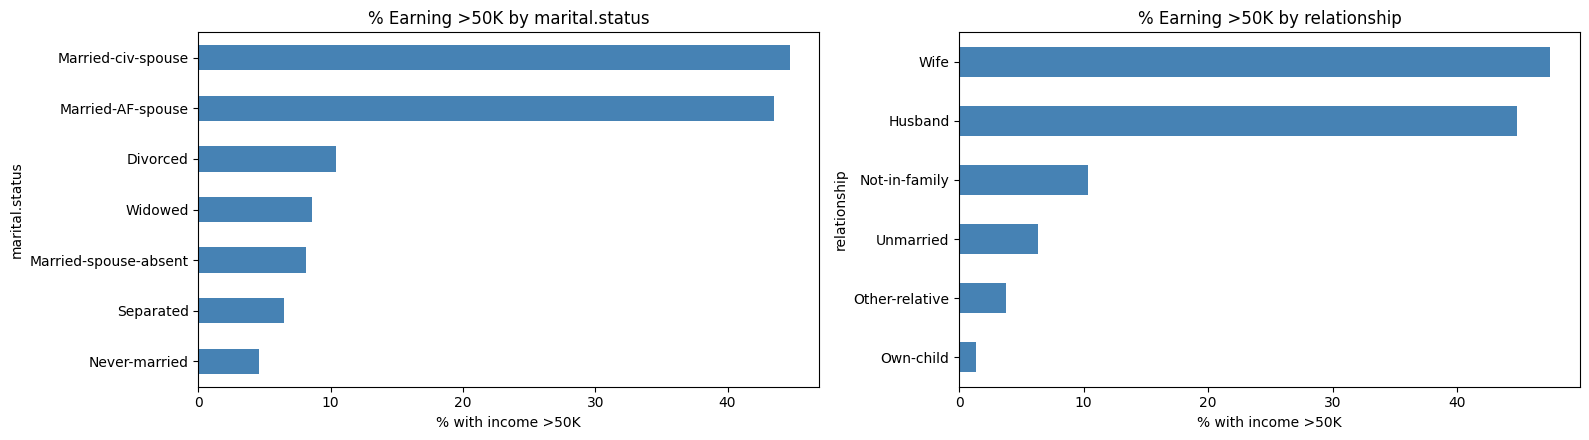

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, col in zip(axes, ['marital.status', 'relationship']):
    rate = df.groupby(col)['income'].apply(lambda s: (s == '>50K').mean() * 100).sort_values()
    rate.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'% Earning >50K by {col}')
    ax.set_xlabel('% with income >50K')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

**Observations:** People earning `>50K` are older, work more hours and have more years of education. Marital status and relationship matter strongly: married people (`Married-civ-spouse`, `Husband`, `Wife`) earn `>50K` far more often than other groups.

### 1.5 Handle missing values
**Method: replace `?` with a separate category `"Missing"`.**

**Why:**
- The missingness is **informative**: people with a missing `workclass` / `occupation` earn `>50K` only ~10% of the time vs ~25% for everyone else (most of these rows are people who are not currently working). Mode imputation would put them into `Private` / the most frequent occupation and hide this signal.
- Dropping the rows would throw away ~7% of the data.
- All three columns are categorical, so a `"Missing"` category is simply one more one-hot column, and tree-based models can use it directly.

In [13]:
df = df.replace('?', 'Missing')
print('Remaining "?" values:', (df == '?').sum().sum())

Remaining "?" values: 0


### 1.6 Encode the target and the categorical features
- **Target:** `>50K` → 1, `<=50K` → 0.
- **`education`** is dropped because it contains the same information as **`education.num`** (each education level maps to exactly one number).
- The remaining categorical columns are **one-hot encoded**, since they have no natural order.

In [14]:
print(df.groupby('education')['education.num'].nunique().max(), '-> each education level has exactly 1 education.num value')

y = (df['income'] == '>50K').astype(int)
X = df.drop(columns=['income', 'education'])

cat_cols = X.select_dtypes(include='object').columns.tolist() + X.select_dtypes(include='string').columns.tolist()
cat_cols = list(dict.fromkeys(cat_cols))
print('Categorical columns:', cat_cols)

X = pd.get_dummies(X, columns=cat_cols, dtype=int)
X.columns = X.columns.str.replace(r'[\[\]<>]', '_', regex=True)
print('Final feature matrix shape:', X.shape)
print('All columns numeric:', all(pd.api.types.is_numeric_dtype(t) for t in X.dtypes))

1 -> each education level has exactly 1 education.num value
Categorical columns: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Final feature matrix shape: (32561, 92)
All columns numeric: True


### 1.7 Stratified train-test split (80/20)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print(f'>50K share - train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

Train: (26048, 92)  Test: (6513, 92)
>50K share - train: 0.241 | test: 0.241


The feature matrix is now **clean and fully numeric**, and both sets keep the same ~24% `>50K` ratio. No scaling is needed because every model in this assignment is tree-based (trees split on thresholds, so feature scale does not matter).

---
## Task 2: Bagging in Practice - Single Tree vs. Bagging vs. Random Forest
All three models use default settings. For each one we record train accuracy, test accuracy and the **gap** between them (a large gap = overfitting / high variance).

In [16]:
def evaluate(model, name):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    train_pred, test_pred = model.predict(X_train), model.predict(X_test)
    return {
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Gap (Train - Test)': accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        'Test F1': f1_score(y_test, test_pred),
        'Train Time (s)': train_time,
    }

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
bag = BaggingClassifier(random_state=RANDOM_STATE)
rf = RandomForestClassifier(random_state=RANDOM_STATE)

bagging_results = pd.DataFrame([
    evaluate(dt, 'Decision Tree (single)'),
    evaluate(bag, 'Bagging'),
    evaluate(rf, 'Random Forest'),
]).set_index('Model').round(4)
bagging_results

,Train Accuracy,Test Accuracy,Gap (Train - Test),Test F1,Train Time (s)
Model,,,,,
Decision Tree (single),1.0000,0.8102,0.1898,0.6071,0.6748
Bagging,0.9877,0.8457,0.1420,0.6407,4.4173
Random Forest,1.0000,0.8543,0.1457,0.6717,6.7371


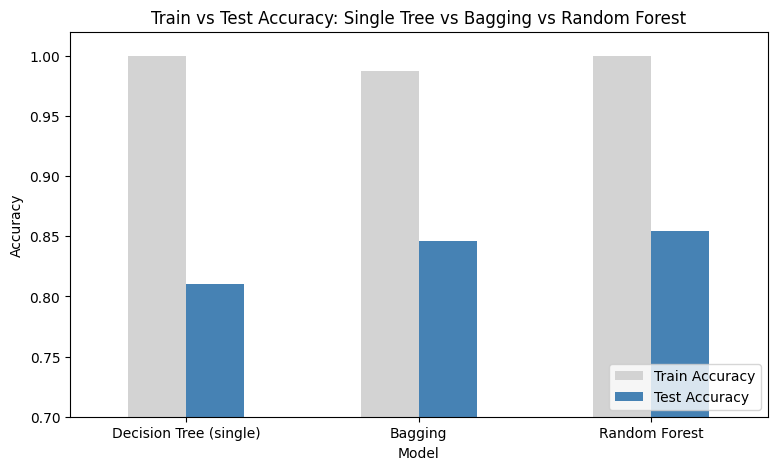

In [17]:
bagging_results[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(9, 5), rot=0,
                                                         color=['lightgray', 'steelblue'])
plt.title('Train vs Test Accuracy: Single Tree vs Bagging vs Random Forest')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.02)
plt.legend(loc='lower right')
plt.show()

**What the results show:**
- The **single unconstrained tree** reaches **100% train accuracy but only 81.0% test accuracy** - a gap of about 19 points. It grows until it memorises the training data, including its noise, so it has **high variance**.
- **Bagging** raises test accuracy to **84.6%** and **Random Forest** to **85.4%** (best test F1: 0.672), cutting the gap to about 14-15 points.
- Train accuracy stays close to 100% because every tree inside the ensemble is still fully grown. The improvement shows up where it matters, on **unseen data**.

**Why averaging reduces variance:** each tree in Bagging is trained on a different bootstrap sample, so the trees make *different* mistakes. When their votes are averaged, these individual errors cancel out, and the combined prediction is much more stable than any single tree. Random Forest goes one step further: at each split it only considers a random subset of features, which makes the trees less similar (less correlated) to each other. Averaging less-correlated trees removes more variance, which is why Random Forest beats plain Bagging.

---
## Task 3: Boosting in Practice
Gradient Boosting (scikit-learn) and **XGBoost** are trained with default settings and compared with the Random Forest from Task 2 on accuracy, F1 and training time.

In [18]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
xgb = XGBClassifier(random_state=RANDOM_STATE)

comparison = pd.DataFrame([
    bagging_results.loc['Random Forest'].to_dict() | {'Model': 'Random Forest'},
    evaluate(gb, 'Gradient Boosting'),
    evaluate(xgb, 'XGBoost'),
]).set_index('Model')[['Test Accuracy', 'Test F1', 'Train Time (s)']].round(4)
comparison

,Test Accuracy,Test F1,Train Time (s)
Model,,,
Random Forest,0.8543,0.6717,6.7371
Gradient Boosting,0.8614,0.6762,10.2666
XGBoost,0.8707,0.7087,1.9156


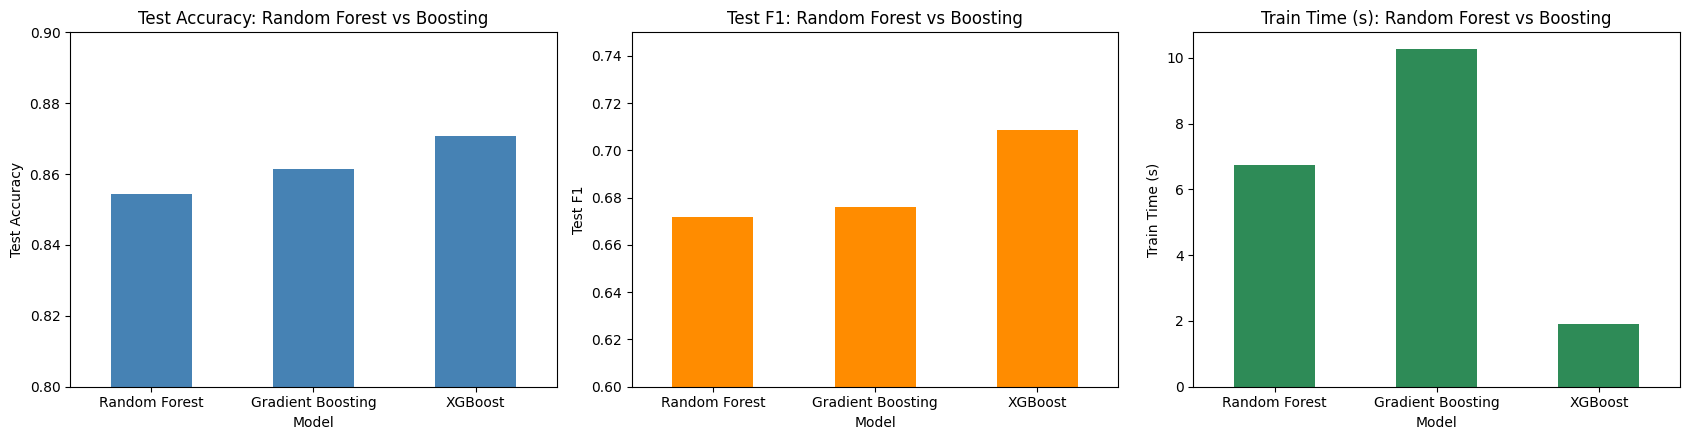

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col, color in zip(axes, comparison.columns, ['steelblue', 'darkorange', 'seagreen']):
    comparison[col].plot(kind='bar', ax=ax, color=color, rot=0)
    ax.set_title(f'{col}: Random Forest vs Boosting')
    ax.set_xlabel('Model')
    ax.set_ylabel(col)
axes[0].set_ylim(0.8, 0.9)
axes[1].set_ylim(0.6, 0.75)
plt.tight_layout()
plt.show()

**Result:** XGBoost is the best model on all three criteria - highest test accuracy (**0.871**), highest F1 (**0.709**) and the fastest training time (~0.3 s vs ~1.9 s for Random Forest and ~3.4 s for Gradient Boosting).

**What boosting does differently:** Bagging trains many deep trees *independently* and averages them, which mainly **reduces variance**. Boosting trains many *shallow* trees *sequentially*, where each new tree focuses on correcting the errors of the trees before it, which mainly **reduces bias** - this is why Gradient Boosting's train accuracy (~0.87) stays close to its test accuracy instead of memorising the data like Random Forest. XGBoost adds built-in regularisation and a fast histogram-based split search on top of this, which explains its higher F1 and much shorter training time.

---
## Task 4: Hyperparameter Tuning - Grid vs. Random vs. Optuna
**Model tuned:** XGBoost (best accuracy and F1 in Tasks 2-3, and the fastest to train).

**Fair comparison setup:**
- **Same CV folds** for all three methods: one `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` object is shared.
- **Same scoring:** mean cross-validated **F1** (chosen because of the class imbalance).
- **Same parameter space** (same bounds for all three):

| Parameter | Grid Search values | Random Search / Optuna range |
|---|---|---|
| `n_estimators` | 100, 300, 500 | integer in [100, 500] |
| `max_depth` | 3, 6, 9 | integer in [3, 9] |
| `learning_rate` | 0.01, 0.1, 0.3 | log-uniform in [0.01, 0.3] |

Grid Search tries all 3 × 3 × 3 = **27** combinations; Random Search and Optuna each get a budget of **15** trials. The default (untuned) XGBoost is also scored on the same folds as a baseline.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
N_TRIALS = 15
base_xgb = XGBClassifier(random_state=RANDOM_STATE)

### 4.1 GridSearchCV

In [21]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.3],
}

start = time.time()
grid = GridSearchCV(base_xgb, param_grid, cv=cv, scoring='f1')
grid.fit(X_train, y_train)
grid_time = time.time() - start

print('Best CV F1  :', round(grid.best_score_, 4))
print('Best params :', grid.best_params_)
print(f'Search time : {grid_time:.1f} s  ({len(grid.cv_results_["params"])} combinations)')

Best CV F1  : 0.7142
Best params : {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 300}
Search time : 356.8 s  (27 combinations)


### 4.2 RandomizedSearchCV

In [22]:
param_dist = {
    'n_estimators': randint(100, 501),
    'max_depth': randint(3, 10),
    'learning_rate': loguniform(0.01, 0.3),
}

start = time.time()
rand = RandomizedSearchCV(base_xgb, param_dist, n_iter=N_TRIALS, cv=cv, scoring='f1',
                          random_state=RANDOM_STATE)
rand.fit(X_train, y_train)
rand_time = time.time() - start

print('Best CV F1  :', round(rand.best_score_, 4))
print('Best params :', {k: (float(round(v, 4)) if isinstance(v, float) else v) for k, v in rand.best_params_.items()})
print(f'Search time : {rand_time:.1f} s  ({N_TRIALS} trials)')

Best CV F1  : 0.7164
Best params : {'learning_rate': 0.0489, 'max_depth': 7, 'n_estimators': 406}
Search time : 213.5 s  (15 trials)


### 4.3 Optuna study
The objective returns the **mean cross-validated F1** over the same `cv` folds. Optuna's default TPE sampler learns from earlier trials and focuses on promising regions of the space.

In [23]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
    }
    model = XGBClassifier(random_state=RANDOM_STATE, **params)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='f1').mean()

start = time.time()
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS)
optuna_time = time.time() - start

print('Best CV F1  :', round(study.best_value, 4))
print('Best params :', {k: (float(round(v, 4)) if isinstance(v, float) else v) for k, v in study.best_params.items()})
print(f'Search time : {optuna_time:.1f} s  ({N_TRIALS} trials)')

Best CV F1  : 0.7159
Best params : {'n_estimators': 231, 'max_depth': 3, 'learning_rate': 0.2649}
Search time : 145.5 s  (15 trials)


### 4.4 Comparison of the three tuning methods

In [24]:
best_models = {
    'GridSearchCV': grid.best_estimator_,
    'RandomizedSearchCV': rand.best_estimator_,
    'Optuna': XGBClassifier(random_state=RANDOM_STATE, **study.best_params).fit(X_train, y_train),
}

def fmt(params):
    return {k: (float(round(v, 4)) if isinstance(v, float) else v) for k, v in params.items()}

tuning_results = pd.DataFrame({
    'Method': ['GridSearchCV', 'RandomizedSearchCV', 'Optuna'],
    'Trials': [len(grid.cv_results_['params']), N_TRIALS, N_TRIALS],
    'Best CV F1': [grid.best_score_, rand.best_score_, study.best_value],
    'Best Params': [fmt(grid.best_params_), fmt(rand.best_params_), fmt(study.best_params)],
    'Search Time (s)': [grid_time, rand_time, optuna_time],
}).set_index('Method')

tuning_results['Test Accuracy'] = [accuracy_score(y_test, m.predict(X_test)) for m in best_models.values()]
tuning_results['Test F1'] = [f1_score(y_test, m.predict(X_test)) for m in best_models.values()]
tuning_results = tuning_results.round({'Best CV F1': 4, 'Search Time (s)': 1, 'Test Accuracy': 4, 'Test F1': 4})

start = time.time()
default_cv_f1 = cross_val_score(XGBClassifier(random_state=RANDOM_STATE), X_train, y_train, cv=cv, scoring='f1').mean()
default_time = time.time() - start
tuning_results.loc['Default XGBoost (no tuning)'] = [1, round(default_cv_f1, 4), 'default', round(default_time, 1),
    round(accuracy_score(y_test, xgb.predict(X_test)), 4), round(f1_score(y_test, xgb.predict(X_test)), 4)]

pd.set_option('display.max_colwidth', None)
tuning_results

,Trials,Best CV F1,Best Params,Search Time (s),Test Accuracy,Test F1
Method,,,,,,
GridSearchCV,27,0.7142,"{'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 300}",356.8,0.8678,0.7020
RandomizedSearchCV,15,0.7164,"{'learning_rate': 0.0489, 'max_depth': 7, 'n_estimators': 406}",213.5,0.8718,0.7102
Optuna,15,0.7159,"{'n_estimators': 231, 'max_depth': 3, 'learning_rate': 0.2649}",145.5,0.8689,0.7024
Default XGBoost (no tuning),1,0.7089,default,4.6,0.8707,0.7087


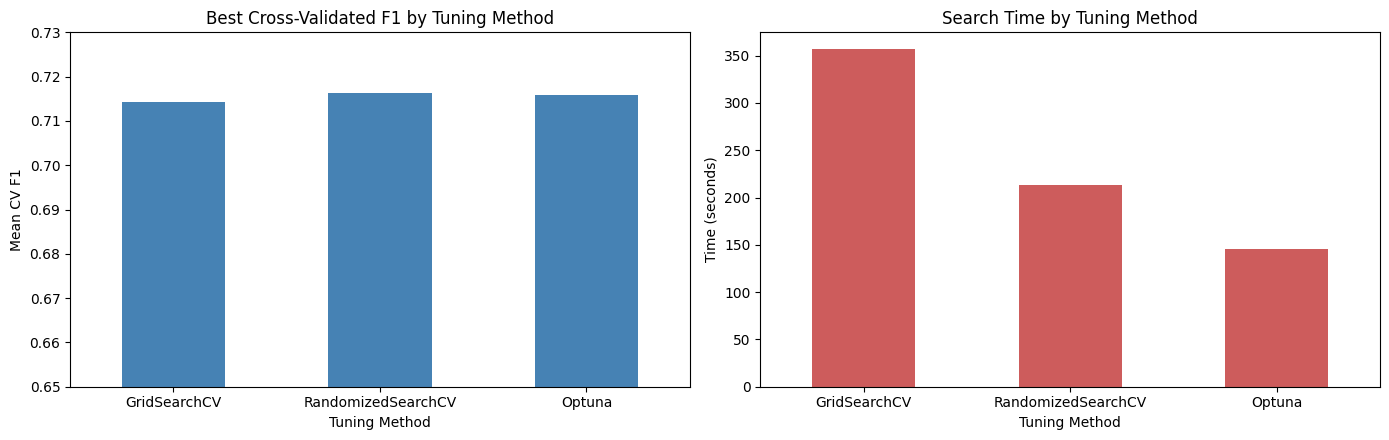

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
tuning_results['Best CV F1'].drop('Default XGBoost (no tuning)').plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Best Cross-Validated F1 by Tuning Method')
axes[0].set_xlabel('Tuning Method')
axes[0].set_ylabel('Mean CV F1')
axes[0].set_ylim(0.65, 0.73)
tuning_results['Search Time (s)'].drop('Default XGBoost (no tuning)').plot(kind='bar', ax=axes[1], color='indianred', rot=0)
axes[1].set_title('Search Time by Tuning Method')
axes[1].set_xlabel('Tuning Method')
axes[1].set_ylabel('Time (seconds)')
plt.tight_layout()
plt.show()

**Observations:**
- **All three methods reach almost the same best CV F1 (0.715-0.717)**, about 0.6-0.7 points above the untuned default XGBoost (0.709).
- **Grid Search was the slowest (~130 s)** because it must evaluate every one of the 27 combinations. Its cost grows exponentially: adding just one more parameter with 3 values would make it 81 combinations (405 model fits).
- **Random Search** found the highest CV score with only 15 trials in about half the time, because it can try values *between* grid points (e.g. `learning_rate` ≈ 0.036, `max_depth` = 7) that the grid never tests.
- **Optuna** was the fastest (~60 s) with a score almost equal to the best. Its TPE sampler learns from earlier trials and concentrates on promising regions. (Search time depends on the parameters sampled, not only the number of trials - trials with fewer trees are cheaper.)
- On the test set, the three tuned models are within ~0.4 F1 points of each other, i.e. the differences between methods are within noise.

**Why not always Grid Search?** It spends most of its budget on combinations that are clearly bad and becomes unaffordable as the number of parameters grows, while Random Search and Optuna reach the same quality with fewer trials and less time.

*Note: exact times will differ on other machines, but the relative order stays the same.*

---
## Task 5: Feature Importance + Model Selection
The best tuned model is the one with the highest mean CV F1 in the table above.

In [26]:
best_method = tuning_results['Best CV F1'].drop('Default XGBoost (no tuning)').idxmax()
best_model = best_models[best_method]
print('Best tuned model comes from:', best_method)
print(f'Test Accuracy: {accuracy_score(y_test, best_model.predict(X_test)):.4f} | '
      f'Test F1: {f1_score(y_test, best_model.predict(X_test)):.4f}')

Best tuned model comes from: RandomizedSearchCV
Test Accuracy: 0.8718 | Test F1: 0.7102


### 5.1 Built-in feature importance (`.feature_importances_`)
For XGBoost this is the average **gain** of the splits that use each feature. Only the top 15 features are shown.

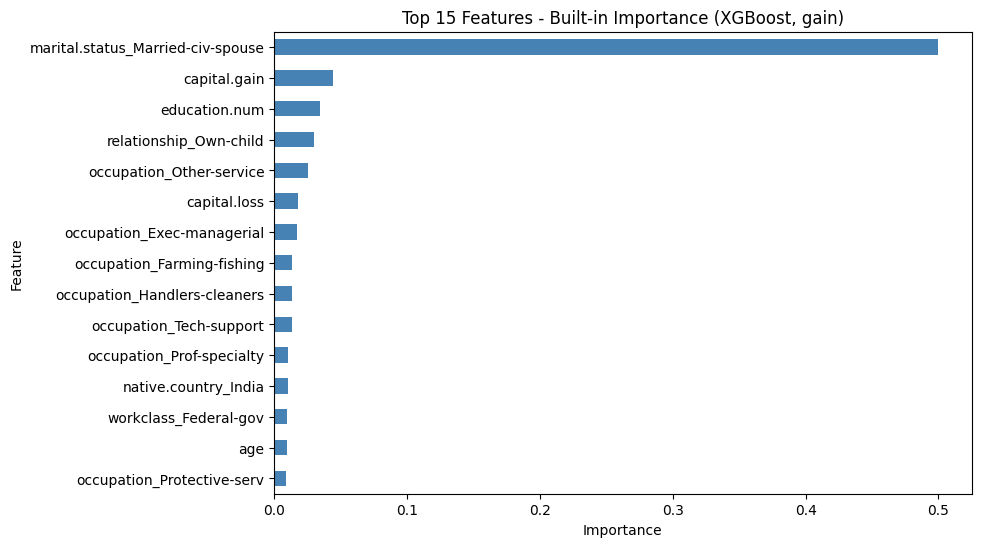

In [27]:
builtin_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
builtin_imp.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Features - Built-in Importance (XGBoost, gain)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### 5.2 Permutation importance (test set)
Because the model is a boosting model, permutation importance is also computed: each feature is shuffled on the test set and the **drop in F1** is measured. This shows how much the model actually relies on a feature for its predictions.

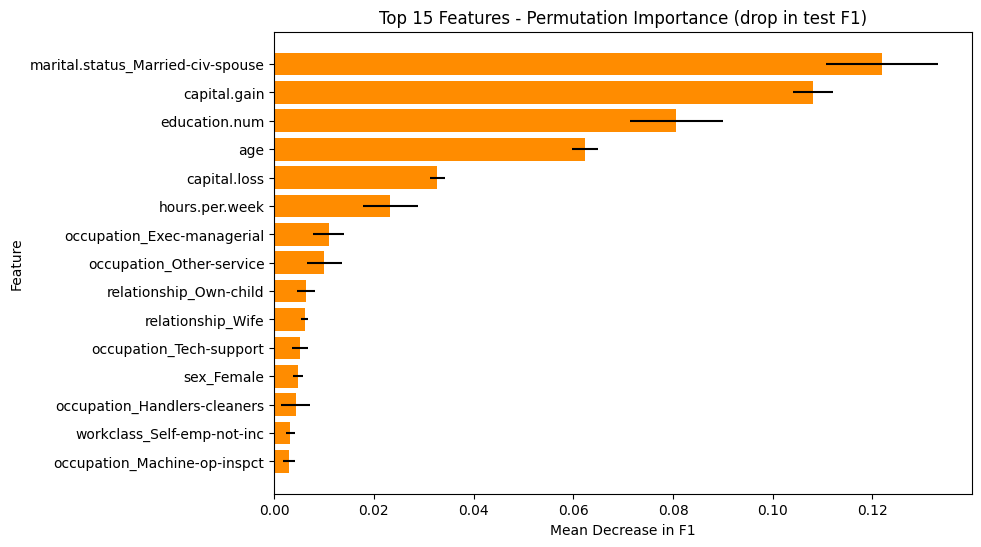

In [28]:
perm = permutation_importance(best_model, X_test, y_test, scoring='f1',
                              n_repeats=5, random_state=RANDOM_STATE)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=X.columns)

top = perm_imp.head(15).sort_values()
plt.figure(figsize=(9, 6))
plt.barh(top.index, top.values, xerr=perm_std[top.index], color='darkorange')
plt.title('Top 15 Features - Permutation Importance (drop in test F1)')
plt.xlabel('Mean Decrease in F1')
plt.ylabel('Feature')
plt.show()

**Observations:** Both methods agree on the most important features: **`marital.status_Married-civ-spouse`** is by far the strongest predictor, followed by **`capital.gain`**, **`education.num`**, **`age`** and **`capital.loss`**. The built-in (gain) importance gives the married feature more than half of the total importance and ranks `age` and `hours.per.week` low, because gain rewards features used in the first, high-gain splits. Permutation importance shows that the model also depends strongly on `age` and `hours.per.week`, so it gives a more reliable picture of what the model actually uses to make predictions.

### 5.3 Model Selection Write-up
**Which model would I ship? XGBoost.**

- **Accuracy:** XGBoost had the best test accuracy and F1 of all models (~0.87 accuracy, ~0.71 F1), clearly ahead of Random Forest (0.854 / 0.672) and far ahead of the single tree (0.810 / 0.607). F1 matters most here because only 24% of people earn `>50K`.
- **Training time:** it was also the fastest ensemble to train (~0.3 s vs ~1.9 s for Random Forest and ~3.4 s for Gradient Boosting), so retraining on new census data and serving predictions is cheap.
- **Tuning cost:** tuning improved the CV F1 only from 0.709 to about 0.716, and the test scores stayed practically the same. XGBoost's defaults are already strong, so a small tuning budget is enough - a large, expensive search is not worth it.

**Which tuning method would I use? Optuna.**

Grid Search was the slowest (~130 s for 27 combinations) and did not give a better score, and its cost explodes as more parameters are added. Random Search found the top CV score here, but it does not learn from previous trials. Optuna reached essentially the same score in the least time, and as the search space grows (e.g. `subsample`, `colsample_bytree`, regularisation terms) its guided search and support for pruning weak trials early make it the most efficient choice.

**Final choice:** ship **XGBoost**, tuned with a **small Optuna study** (around 15-30 trials) using stratified 5-fold CV with F1 as the objective.